# **Equazioni non lineari**

Si consideri il problema della ricerca degli zeri dell'equazione non
lineare $f(x)=0$, dove $f$ è definita da:
\begin{equation}
f(x):=e^{x}-x^{2}-\textrm{sin}(x)-1,\qquad x\in[-2,2]\;.
\end{equation}

# **Rappresentazione grafica della funzione**          

Disegnare il grafico della funzione $f$ e la retta $y=0$ in modo da evidenziare le due soluzioni dell'equazione.

In [2]:
# step 0 -> ricordarsi di importare i pacchetti numpy and matplotlib

import numpy as np
import matplotlib.pyplot as plt

Vediamo un nuovo costrutto utile per costruire funzioni matematiche "lambda function" in modo semplice e veloce.


      f = lambda nome_variabili: espressione della funzione

In [ ]:
# esempi di lambda function
f = lambda t: np.sin(t*np.pi)
# la variabile è locale e quindi queste du funzioni sono uguali
g = lambda x: np.sin(x*np.pi)
# funzione con più variabili
h = lambda x, y, z: x+2*y+2*z

# altro modo di scrivere una function
# def f(t): return np.sin(t*np.pi)
# la variabile è locale e quindi queste du funzioni sono uguali
# def g(x): return np.sin(x*np.pi)
# funzione con più variabili
# def h(x, y, z): return x+2*y+2*z

print("valuto la funzione f in 0.5: %f" % f(0.5))
print("valuto la funzione g in 0.5: %f" % g(0.5))
print("valuto la funzione h in (1,2,3): %f" % h(1, 2, 3))

valuto la funzione f in 0.5: 1.000000
valuto la funzione g in 0.5: 1.000000
valuto la funzione h in (1,2,3): 11.000000


Scrivere la funzione $f$ dell'esercizio usando la lambda function

In [ ]:
# lambda function della funzione f
f = lambda x : np.exp(x) - x**2 - np.sin(x) - 1.0
# oppure def f(x): return np.exp(x) - x**2 - np.sin(x) - 1.0

Rappresentazione grafica

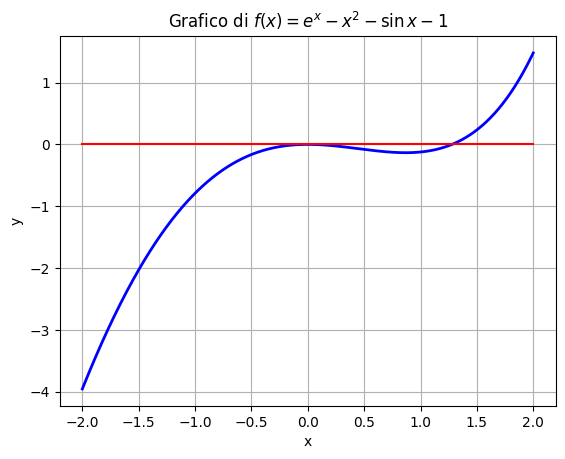

In [5]:
# rappresentazione grafica
# discretizzazione dell'intervallo [-2 2]
xgrid = np.linspace(-2, 2, 1000)
# plot di f
plt.plot(xgrid, f(xgrid), 'b-', linewidth=2.0)
# plot asse y=0
# o semplicemente plt.plot([-2,2],[0,0],'r-')
plt.plot(xgrid, np.zeros(np.shape(xgrid)), 'r-')
# specifiche grafiche titolo, legenda, grid,
plt.title("Grafico di $f(x)=e^x-x^2-\\sin x-1$")
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.show()

# **Bisezione**


<mark>**Domanda:**</mark></br>
 Il metodo di bisezione è applicabile per calcolare
entrambe le radici? Motivare la risposta.



<mark>**Esercizio 1.1: implementazione bisezione**</mark></br>

Scrivere una function $\verb|bisez|$ che implementi il metodo di bisezione. L'intestazione della funzione sarà ad esempio la seguente:


      def bisez(f,a,b,toll):
      #
      # implementazione di bisezione
      #
      return xvect


Tale funzione riceve in input:
* $\verb|f|→$ funzione di cui vogliamo calcolare gli zeri,
* $a→$ primo estremo
* $b→$ secondo estremo
* $\verb|toll|→$ tolleranza richiesta

e in out
* $\verb|xvect|→$ il vettore delle iterate.




In [6]:
# definizione del metodo di bisezione
def bisez(f, a, b, toll=1e-6):

    # controllo se gli estremi sono una bracket (opzionale)
    if (f(a)*f(b) >= 0):
        raise RuntimeError('ERRORE: l''intervallo [a,b] non è una bracket')

    # inizializzazione
    xvect = []

    while (abs(b-a) > toll):
        x = 0.5*(a+b)

        # primo controllo se x è uno zero (opzionale)
        if (f(x) == 0):
            xvect.append(x)
            print("x è esattamente uno zero della funzione")
            break

        # metodo di bisezione
        if (f(a)*f(x) > 0):
            a = x
        else:
            b = x

        xvect.append(x)

    return np.array(xvect)

<mark>**Esercizio 1.2**</mark></br>
Quando è possibile, applicare il metodo di bisezione alla funzione $f$.
Stampare il numero di iterazioni, lo zero trovato $x^*$ e il valore della funzione $f(x^*)$.

In [7]:
# scelta degli estremi a,b
a, b = 1, 1.5
xvect = bisez(f, a, b, 1e-12)

x0 = xvect[-1]
print("Numero iterazioni: %d." % len(xvect))
print("Ultimo valore di x: %f" % x0)
print("Ultimo valore di f: %.e\n" % f(x0))

Numero iterazioni: 39.
Ultimo valore di x: 1.279701
Ultimo valore di f: 7e-13



**Alcuni commenti finali sul metodo di bisezione**

Dalla teoria sappiamo che:

*   Il metodo di bisezione è convergente e abbiamo una stima dell'errore (anche senza dover sapere la soluzione esatta)

\begin{equation}
|e^k| \le \frac{1}{2^{k+1}} |b-a| .
\end{equation}

*   Se voglio ottenere una soluzione esatta a meno di una tolleranza $eps$

\begin{equation}
k > \log_2 \frac{|b-a|}{eps} - 1 .
\end{equation}

*   La convergenza del metodo di bisezione è lenta (l'errore non sempre decresce monotonicamente).

*   Se uno zero ha molteplicità dispari, allora vale il teorema degli zeri. Nel caso di molteplicità pari, non è garantito.

# **Metodo di Newton**

<mark>**Domanda:**</mark></br>
Discutere le proprietà  di convergenza del metodo di Newton per
  entrambi gli zeri, valutando l'opportunità  di applicare il metodo
  di Newton.





<mark>**Esercizio 2.1: implementazione Newton**</mark></br>
Scrivere una function $\verb|newton|$ che implementi il metodo di Newton. L'intestazione della funzione sarà ad esempio la seguente:


      def newton (f,df,x0,nmax,toll)
      #
      # implementazione del metodo di newton
      #
      return xvect

Tale funzione riceve in input:
* $\verb|f|→$ funzione di cui vogliamo calcolare gli zeri,
* $\verb|df|→$ la derivata della funzione $f$,
* $x_0→$ punto di partenza
* $\verb|nmax|→$ numero massimo di iterazione
* $\verb|toll|→$ tolleranza richiesta

e in out
* $\verb|xvect|→$ il vettore delle iterate.

Si utilizzi un criterio d'arresto basato sul modulo della differenza tra due iterate successive.


In [8]:
# Definizione del metodo di Newton (questa è già la versione modificata)
def newton(f, df, x0, nmax=100, toll=1e-6, m=1):

    xvect = []
    xold = x0

    for nit in range(nmax):
        # verifica che la derivata prima non è nulla
        if (df(xold) == 0):  # if (abs(df(xold)<np.finfo(float).eps): -> questo un altro modo
            raise RuntimeError('ERRORE: Derivata prima nulla \n')
        else:
            # calcolo il nuovo punto
            xnew = xold-m*f(xold)/df(xold)
            # carico i vettori
            xvect.append(xnew)

        # criterio di arresto e aggiorno
        if (abs(xnew-xold) < toll):
            break
        else:
            xold = xnew

    return np.array(xvect)

<mark>**Esercizio 2.2: modifica di Newton**</mark></br>
Si scriva, modificando opportunamente la function $\verb|newton|$,
il metodo di Newton modificato, passando come parametro in ingresso anche la molteplicità dello zero cercato. L'intestazione della funzione sarà la seguente:


      def newton (f,df,x0,nmax,toll,m=1)
        #
        # modificare il passo iteratativo di newton
        #  x^{k+1} = x^k - m f(x^k)/f'(x^k)
        #
        return xvect

dove $\verb|m|$ è la molteplicità dello zero cercato.


<mark>**Esercizio 2.3**</mark></br>

Applicare il metodo di Newton e, quando è il caso, il metodo di Newton modificato (aggiungendo la specifica $\verb|m|$) con tolleranza $10^{-6}$, per la funzione
\begin{equation}
f(x):=e^{x}-x^{2}-\textrm{sin}(x)-1,\qquad x\in[-2,2]\;.
\end{equation}
Riportare su un grafico in scala semilogaritmica l'andamento dell'errore in funzione del numero di iterazioni. Per il calcolo dell'errore si assuma come valore esatto dello zero non nullo, il valore $x=1.279701331000996$. Cosa si osserva nell'ordine di convergenza?


In [9]:
# funzione f e la sua derivata df
def f(t): return np.exp(t) - t**2 - np.sin(t) - 1.0


def df(t): return np.exp(t) - 2*t - np.cos(t)

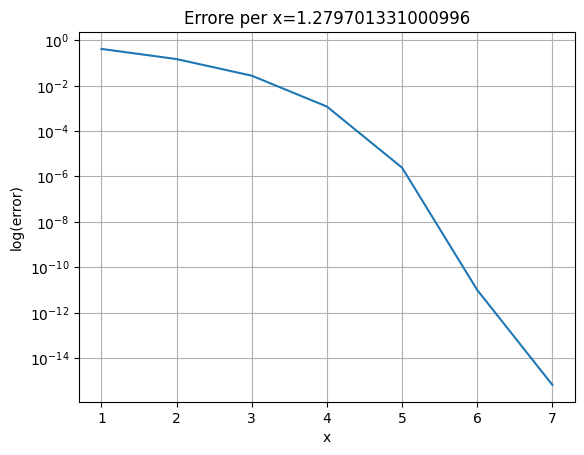

In [10]:
# ricerca dello zero xe=1.279701331000996
xe = 1.279701331000996
# starting point
x0 = 1

xvect = newton(f, df, x0, 100, 1e-6)
# calcolo dell'errore
error = np.abs(xe-xvect)

# rappresentazione grafica dell'errore
plt.semilogy(np.arange(1, len(xvect)+1), error)
plt.title("Errore per x=%.15f" % xe)
plt.xlabel('x')
plt.ylabel('log(error)')
plt.grid()
plt.show()

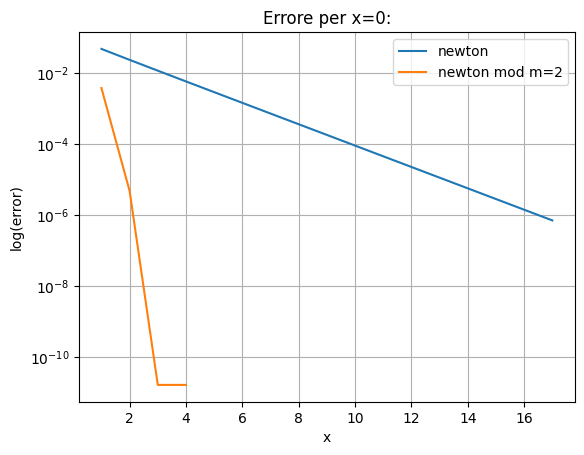

In [11]:
# Ricerca dello zero xe=0
xe = 0
# starting point
x0 = 0.1

# chiamo newton
xvect_n = newton(f, df, x0, 100, 1e-6)
# calcolo dell'errore per newton
error_n = np.abs(xe-xvect_n)

# chiamo newton modificato con m=2
xvect_nm = newton(f, df, x0, 100, 1e-6, m=2)
# calcolo dell'errore per newton modificato
error_nm = np.abs(xe-xvect_nm)

plt.semilogy(np.arange(1, len(xvect_n)+1), error_n)
plt.semilogy(np.arange(1, len(xvect_nm)+1), error_nm)
plt.legend(['newton', 'newton mod m=2'])
plt.title("Errore per x=%d:" % xe)
plt.xlabel('x')
plt.ylabel('log(error)')
plt.grid()
plt.show()

**Alcuni commenti finali sul metodo di Newton**

Dalla teoria sappiamo che:

*   Il metodo di Newton è (SOLO) localmente convergente
*   Se converge, allora converge quadraticamente per zeri di molteplicità 1, linearmente per zeri di molteplicità superiore (in tal caso occorre Newton modificato per ripristinare convergenza ottimale)
*   Il metodo di Newton è un particolare metodo di punto fisso

# **Esercizi per casa**


## **Metodo punto fisso**

Si consideri il problema della ricerca degli zeri dell'equazione non lineare $g(x)=0$, dove $g$ è definita da:
\begin{equation}
g(x):= 4x-e^{x^2},\qquad x\in\left[0,\frac{3}{2}\right]\;.
\end{equation}


<mark>**Esercizio 3.1**</mark></br>
Disegnare il grafico della funzione $g$ e la retta $y=0$ in modo
da evidenziare le due soluzioni dell'equazione. Inoltre, per ogni soluzione, determinare un opportuno intervallo che la contenga.

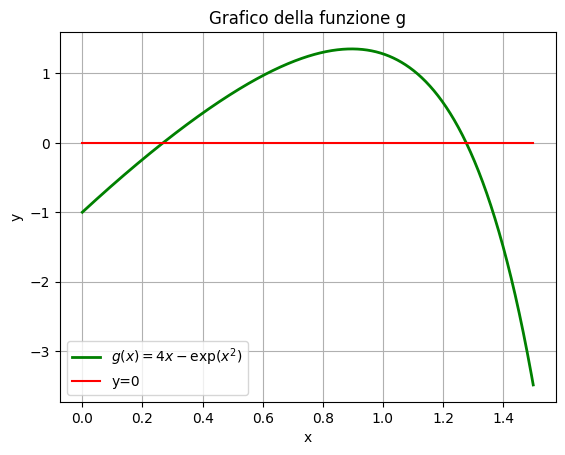

In [19]:
# funzione g
def g(x): return 4*x-np.exp(x**2)


x = np.linspace(0, 1.5, 1000)

# plot della funzione g
plt.plot(x, g(x), '-g', linewidth=2)
plt.plot([0, 1.5], [0, 0], 'r-')
plt.title("Grafico della funzione g")
plt.legend(["$g(x)=4x-\\exp(x^2)$", "y=0"], loc='best')
plt.xlabel("x")
plt.ylabel("y")
plt.grid('major')
plt.show()

**Osservazione sulle soluzioni dell'esercizio 3.1:** Dal grafico precedente si può osservare che ci sono due soluzioni $\alpha_1$ e $\alpha_2$ nell'intervallo considerato, rispettivamente $0.2<\alpha_1 < 0.3$ e $1.2<\alpha_2 < 1.3$.

<mark>**Esercizio 3.2**</mark></br>
Individuare la funzione di iterazione $\phi$ per il metodo di punto fisso e la sua derivata $\phi'(x)$. Plottare $\phi'$ nell'intervallo considerato. Il metodo di punto fisso è applicabile per calcolare
entrambe le radici? Motivare la risposta.

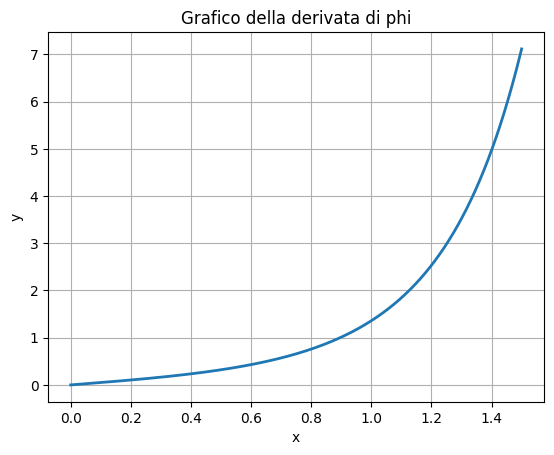

In [13]:
def phi(t): return np.exp(t**2)/4
def dphi(t): return t*np.exp(t**2)/2


plt.plot(x, dphi(x), linewidth=2)
plt.title("Grafico della derivata di phi")
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.show()

**Motivazione esercizio 3.2:** la funzione $\phi$ è continua e derivabile in ogni intorno dei suoi due punti fissi, che coincidono con gli zeri $\alpha_1$ e $\alpha_2$ di $g$.

Osservando il grafico di $\phi'$ quello che si osserva è per $\alpha_1$ valogono le ipotesi del teorema di convergenza del metodo di punto fisso e cioè in un intorno $I_1$ di $\alpha_1$: $$|\phi'(x)|<1 \ \forall x\in I_1.$$
Di conseguenza, esiste $\delta>0$ per cui il metodo di punto fisso definito dalla sequenza $x^{k+1}=\phi(x^k)$, $k\geq 0$, converge a $\alpha_1$ $\forall x_0$ tale che $|x_0-\alpha_1|<\delta$.

Invece, in ogni intorno $I_2$ di $\alpha_2$ esiste un punto $\bar{x}$ tale che $|\phi'(\bar{x})|\geq 1$. Di conseguenza il metodo di punto fisso potrebbe non convergere ad $\alpha_2$.


<mark>**Esercizio 3.3**</mark></br>

Scrivere la function $\verb|puntofisso|$ che implementi il metodo di punto fisso. L'intestazione della funzione sarà ad esempio la seguente:


      def puntofisso (phi,x0,nmax,toll)
        #
        # implementazione del metodo di newton
        #
        return xvect

Tale funzione riceve in input:
* $\verb|phi|→$ funzione di iterazione,
* $x_0→$ punto di partenza
* $\verb|nmax|→$ numero massimo di iterazione
* $\verb|toll|→$ tolleranza richiesta

e in out
* $\verb|xvect|→$ il vettore delle iterate.

Si utilizzi un criterio d'arresto basato sul modulo della differenza tra due iterate successive.

In [14]:
def puntofisso(phi, x0, nmax=100, toll=1.e-6):

    # inizializzazione
    xvect = []
    xold = x0

    for nit in range(nmax):
        # calcolo il nuovo punto
        xnew = phi(xold)
        # carico i vettori
        xvect.append(xnew)

        # criterio di arresto e aggiorno
        if (abs(xnew-xold) < toll):
            break
        else:
            xold = xnew

    return np.array(xvect)

<mark>**Esercizio 3.3**</mark></br>
Applicare il metodo, quando possibile, con numero massimo di iterazioni $\verb|nmax|=100$ e tolleranza pari a
$10^{-5}$, utilizzando la funzione $\verb|puntofisso|$ e dati iniziali $x0=0$, $x0=1.5$.

In [15]:
# verifica del metodo di punto fisso
# dati
nmax = 100
toll = 1e-5

for x0 in [0, 1.5]:
    xvect = puntofisso(phi, x0, nmax, toll)
    print("Dato iniziale x0=%.1f" % x0)
    print("Numero di iterazione: %d" % len(xvect))
    print("Radice trovata: %f\n" % xvect[-1])

Dato iniziale x0=0.0
Numero di iterazione: 6
Radice trovata: 0.268719

Dato iniziale x0=1.5
Numero di iterazione: 100
Radice trovata: inf



/tmp/ipykernel_27318/1938367984.py:1: RuntimeWarning: overflow encountered in exp
  def phi(t): return np.exp(t**2)/4
/tmp/ipykernel_27318/1159962735.py:14: RuntimeWarning: invalid value encountered in scalar subtract
  if (abs(xnew-xold) < toll):


## **Bisezione**
<mark>**Esercizio 4.1**</mark></br>
Si consideri il problema della ricerca degli zeri dell'equazione non
lineare $f(x)=0$, dove $f$ è definita da:
\begin{equation}
f(x):=e^{x}-x^{2}-\textrm{sin}(x)-1,\qquad x\in[-2,2]\;.
\end{equation}

Provare ad implementare bisezione con il ciclo for. Ricordo che il numero massimo di iterazioni è
\begin{equation}
 k > \log_2(\frac{|b-a|}{\text{toll}}) -1
\end{equation}
con $k$ un numero intero. Ricordo che nel caso in cui si ottenga un numero non intero nell'espressione a destra allora $k$ va arrotondato al numero intero superiore. Un comando utile per il calcolo di $k$ è $\verb|np.fix|$ (si veda $\verb|help(np.fix)|$).



In [16]:
def bisezfor(f, a, b, toll=1e-6):

    # controllo se gli estremi sono una bracket
    if (f(a)*f(b) >= 0):
        raise RuntimeError('ERRORE: l''intervallo [a,b] non è una bracket')

    # inizializzazione
    nmax = np.fix(np.log2(abs(b-a)/toll)-1)+1

    xvect = []

    for i in range(int(nmax)):
        x = 0.5*(a+b)

        # primo controllo se x è uno zero
        if (f(x) == 0):
            xvect.append(x)
            print("x è esattamente uno zero della funzione")
            break

        # metodo di bisezione
        if (f(a)*f(x) > 0):
            a = x
        else:
            b = x

        xvect.append(x)

    return np.array(xvect)

<mark>**Esercizio 4.2**</mark></br>
Testare la function $\verb|bisezfor|$ nella ricerca degli zeri della funzione $f$.

In [17]:
def f(x): return np.exp(x) - x**2 - np.sin(x) - 1.0


# scelta degli estremi a,b
a, b = 1, 1.5
xvect = bisezfor(f, a, b, 1e-12)

x0 = xvect[-1]
print("Numero iterazioni: %d." % len(xvect))
print("Ultimo valore di x: %f" % x0)
print("Ultimo valore di f: %.e\n" % f(x0))

Numero iterazioni: 38.
Ultimo valore di x: 1.279701
Ultimo valore di f: 1e-12



## **Bisezione e Newton**

<mark>**Esercizio 5**</mark></br>
Si consideri il problema della ricerca degli zeri dell'equazione non
lineare $f(x)=0$, dove $f$ è definita da:
\begin{equation}
f(x):=e^{x}-x^{2}-\textrm{sin}(x)-1,\qquad x\in[-2,2]\;.
\end{equation}
Utilizzare in sequenza il metodo di bisezione e il metodo di Newton per la ricerca dello zero $1 < \alpha_2 < 1.5$; in particolare si adotti il metodo di bisezione per l'avvicinamento allo zero e successivamente il metodo di Newton per la
convergenza "veloce" ad $\alpha_2$, assumendo come punto di innesco lo zero approssimato con il metodo di bisezione. Nello specifico si considerino 5 iterazioni del metodo di bisezione sull'intervallo $[1, 1.5]$ e si assuma come tolleranza per il metodo di Newton il valore $10^{-10}$.





In [18]:
# estremi dell'intervallo
a = 1
b = 1.5
def f(x): return np.exp(x) - x**2 - np.sin(x) - 1.0
def df(x): return np.exp(x) - 2*x - np.cos(x)


nmax = 5
toll_b = 1.e-3
# oppure si poteva anche modificare bisezione introducendo un criterio d'arresto sul numero massimo di iterazioni
nmax_n = 100
toll_n = 1e-10

xvect_b = bisez(f, a, b, toll_b)
xvect_n = newton(f, df, xvect_b[nmax-1], nmax_n, toll_n)
xvect = np.concatenate([xvect_b[0:nmax], xvect_n])

x = xvect[-1]
print("Numero iterazioni: %d." % len(xvect))
print("Ultimo valore di x: %1.10f" % x)
print("Ultimo valore di f: %.e" % f(x))

Numero iterazioni: 9.
Ultimo valore di x: 1.2797013310
Ultimo valore di f: -3e-16
